In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

In [97]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [98]:
df = pd.read_csv("F:/Jupyter Projects/Phitron AL ML/Dataset/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [99]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
392,393,0,3,"Gustafsson, Mr. Johan Birger",male,28.0,2,0,3101277,7.9250,NaN,S
92,93,0,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.1750,E31,S
372,373,0,3,"Beavan, Mr. William Thomas",male,19.0,0,0,323951,8.0500,NaN,S
457,458,1,1,"Kenyon, Mrs. Frederick R (Marion)",female,NaN,1,0,17464,51.8625,D21,S
157,158,0,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.0500,NaN,S
718,719,0,3,"McEvoy, Mr. Michael",male,NaN,0,0,36568,15.5000,NaN,Q
286,287,1,3,"de Mulder, Mr. Theodore",male,30.0,0,0,345774,9.5000,NaN,S
408,409,0,3,"Birkeland, Mr. Hans Martin Monsen",male,21.0,0,0,312992,7.7750,NaN,S
819,820,0,3,"Skoog, Master. Karl Thorsten",male,10.0,3,2,347088,27.9000,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0000,B94,S


In [100]:
df.drop(columns = ['PassengerId'], inplace = True)

In [101]:
df.sample(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
654,0,3,"Hegarty, Miss. Hanora ""Nora""",female,18.0,0,0,365226,6.7500,NaN,Q
302,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0000,NaN,S
279,1,3,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0,1,1,C.A. 2673,20.2500,NaN,S
846,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
614,0,3,"Brocklebank, Mr. William Alfred",male,35.0,0,0,364512,8.0500,NaN,S
459,0,3,"O'Connor, Mr. Maurice",male,NaN,0,0,371060,7.7500,NaN,Q
468,0,3,"Scanlan, Mr. James",male,NaN,0,0,36209,7.7250,NaN,Q
179,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0000,NaN,S
524,0,3,"Kassem, Mr. Fared",male,NaN,0,0,2700,7.2292,NaN,C
374,0,3,"Palsson, Miss. Stina Viola",female,3.0,3,1,349909,21.0750,NaN,S


In [102]:
df.shape

(891, 11)

In [103]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [104]:
# df['Cabin'] = df['Cabin'].fillna('Unknown')

In [105]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [106]:
df.Cabin.value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [107]:
df.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

Purpose:
    Extract titles (Mr, Mrs, Miss, Dr, etc.) from passenger names.

Regex Meaning:
    ' '            → Match a space
    [A-Za-z]+      → One or more letters
    (...)          → Capture the letters
    \.             → Match a literal dot

expand=False:
    Return a Series instead of a DataFrame.

Example:
    "Mr. Owen Harris Braund" → "Mr"
    "Mrs. John Bradley"      → "Mrs"
    "Dr. William Smith"      → "Dr"

In [108]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\HP\AppData\Local\Temp\ipykernel_5188\2347399756.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)


In [109]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1


In [110]:
df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [111]:
df.drop(columns = ['Name', 'Ticket'], inplace = True)

In [112]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,male,22.0,1,0,7.2500,NaN,S,Mr,2
1,1,1,female,38.0,1,0,71.2833,C85,C,Mrs,2
2,1,3,female,26.0,0,0,7.9250,NaN,S,Miss,1
3,1,1,female,35.0,1,0,53.1000,C123,S,Mrs,2
4,0,3,male,35.0,0,0,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S,Rev,1
887,1,1,female,19.0,0,0,30.0000,B42,S,Miss,1
888,0,3,female,NaN,1,2,23.4500,NaN,S,Miss,4
889,1,1,male,26.0,0,0,30.0000,C148,C,Mr,1


In [113]:
df.drop(columns = ['SibSp', 'Parch'], inplace = True)

In [114]:
df

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,male,22.0,7.2500,NaN,S,Mr,2
1,1,1,female,38.0,71.2833,C85,C,Mrs,2
2,1,3,female,26.0,7.9250,NaN,S,Miss,1
3,1,1,female,35.0,53.1000,C123,S,Mrs,2
4,0,3,male,35.0,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,NaN,S,Rev,1
887,1,1,female,19.0,30.0000,B42,S,Miss,1
888,0,3,female,NaN,23.4500,NaN,S,Miss,4
889,1,1,male,26.0,30.0000,C148,C,Mr,1


In [115]:
df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [116]:
df.Title.value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [117]:
title_mapping = {
    'Mr': 'Mr', 
    'Mrs': 'Mrs', 
    'Mme': 'Mrs',
    'Miss': 'Miss', 
    'Mlle': 'Miss', 
    'Ms': 'Miss',
    'Master': 'Master',
    'Don': 'Rare', 
    'Rev': 'Rare', 
    'Dr': 'Rare', 
    'Major': 'Rare', 
    'Lady': 'Rare', 
    'Sir': 'Rare', 
    'Col': 'Rare', 
    'Capt': 'Rare', 
    'Countess': 'Rare', 
    'Jonkheer': 'Rare'
}

df['Title'] = df['Title'].map(title_mapping)
df['Title'] = df['Title'].fillna('Rare')

In [118]:
df.sample(10)

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
35,0,1,male,42.0,52.0000,NaN,S,Mr,2
715,0,3,male,19.0,7.6500,F G73,S,Mr,1
205,0,3,female,2.0,10.4625,G6,S,Miss,2
201,0,3,male,NaN,69.5500,NaN,S,Mr,11
472,1,2,female,33.0,27.7500,NaN,S,Mrs,4
640,0,3,male,20.0,7.8542,NaN,S,Mr,1
835,1,1,female,39.0,83.1583,E49,C,Miss,3
357,0,2,female,38.0,13.0000,NaN,S,Miss,1
458,1,2,female,50.0,10.5000,NaN,S,Miss,1
265,0,2,male,36.0,10.5000,NaN,S,Mr,1


In [119]:
df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
Fare            0
Cabin         687
Embarked        2
Title           0
FamilySize      0
dtype: int64

In [120]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [121]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [122]:
# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [123]:
# df.isnull().sum()

In [124]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [125]:
df.sample(10)

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
159,0,3,male,NaN,69.5500,NaN,S,Master,11
222,0,3,male,51.0,8.0500,NaN,S,Mr,1
487,0,1,male,58.0,29.7000,B37,C,Mr,1
142,1,3,female,24.0,15.8500,NaN,S,Mrs,2
812,0,2,male,35.0,10.5000,NaN,S,Mr,1
610,0,3,female,39.0,31.2750,NaN,S,Mrs,7
358,1,3,female,NaN,7.8792,NaN,Q,Miss,1
643,1,3,male,NaN,56.4958,NaN,S,Mr,1
260,0,3,male,NaN,7.7500,NaN,Q,Mr,1
158,0,3,male,NaN,8.6625,NaN,S,Mr,1


<Axes: xlabel='Age', ylabel='Count'>

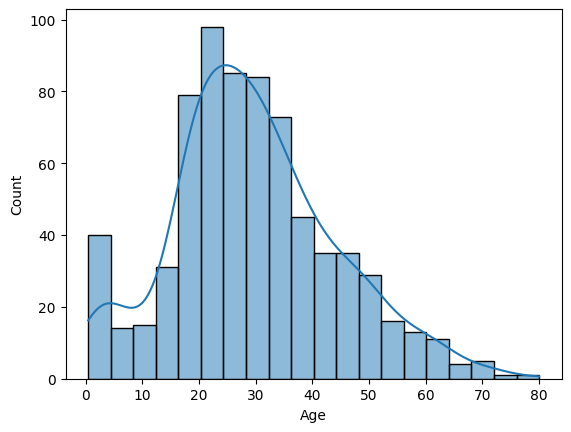

In [126]:
sns.histplot(data = df, x = 'Age', kde = True)

In [127]:
# df.Age.mean() , df.Age.median()

In [128]:
# df['Age'] = df['Age'].fillna(df.Age.median())
# df.isnull().sum()

In [129]:
df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
Fare            0
Cabin         687
Embarked        2
Title           0
FamilySize      0
dtype: int64

In [130]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [131]:
X

,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,3,male,22.0,7.2500,NaN,S,Mr,2
1,1,female,38.0,71.2833,C85,C,Mrs,2
2,3,female,26.0,7.9250,NaN,S,Miss,1
3,1,female,35.0,53.1000,C123,S,Mrs,2
4,3,male,35.0,8.0500,NaN,S,Mr,1
...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,NaN,S,Rare,1
887,1,female,19.0,30.0000,B42,S,Miss,1
888,3,female,NaN,23.4500,NaN,S,Miss,4
889,1,male,26.0,30.0000,C148,C,Mr,1


In [132]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [134]:
X_train.shape

(712, 8)

In [135]:
X_test.shape

(179, 8)

In [136]:
df.sample(5)

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
69,0,3,male,26.0,8.6625,NaN,S,Mr,3
312,0,2,female,26.0,26.0000,NaN,S,Mrs,3
337,1,1,female,41.0,134.5000,E40,C,Miss,1
12,0,3,male,20.0,8.0500,NaN,S,Mr,1
18,0,3,female,31.0,18.0000,NaN,S,Mrs,2


In [140]:
num_features = ['Age','Fare','FamilySize']
cat_features = ['Pclass','Sex','Cabin','Embarked','Title']

num_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'median'))
])

cat_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ],
    remainder = 'passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [142]:
feature_names = num_features + cat_features
X_train_final = pd.DataFrame(X_train_processed, columns = feature_names)
X_test_final = pd.DataFrame(X_test_processed, columns = feature_names)

In [143]:
X_train_final.isnull().sum()

Age           0
Fare          0
FamilySize    0
Pclass        0
Sex           0
Cabin         0
Embarked      0
Title         0
dtype: int64

In [144]:
X_test_final.isnull().sum()

Age           0
Fare          0
FamilySize    0
Pclass        0
Sex           0
Cabin         0
Embarked      0
Title         0
dtype: int64

In [145]:
X_train_final

,Age,Fare,FamilySize,Pclass,Sex,Cabin,Embarked,Title
0,28.5,56.4958,1.0,3,male,G6,S,Mr
1,28.5,0.0,1.0,2,male,G6,S,Mr
2,28.5,221.7792,1.0,1,male,C95,S,Mr
3,18.0,9.35,2.0,3,female,G6,S,Mrs
4,31.0,26.25,3.0,2,female,G6,S,Mrs
...,...,...,...,...,...,...,...,...
707,28.5,7.8792,1.0,3,female,G6,Q,Miss
708,35.0,512.3292,1.0,1,female,G6,C,Miss
709,48.0,34.375,5.0,3,female,G6,S,Mrs
710,47.0,38.5,1.0,1,male,E63,S,Mr


<Axes: xlabel='Embarked', ylabel='count'>

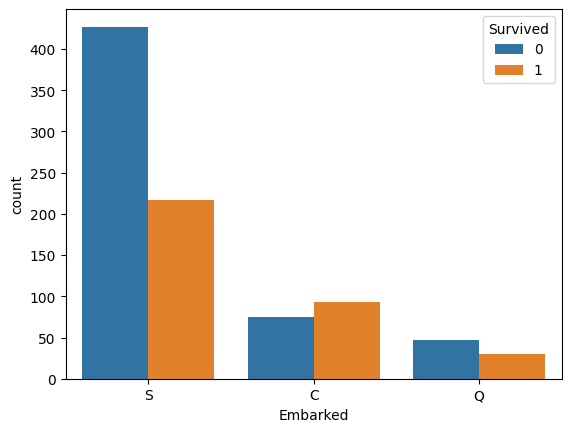

In [147]:
sns.countplot(data=df, x='Embarked', hue='Survived')

In [148]:
X_train_final.head(2)

,Age,Fare,FamilySize,Pclass,Sex,Cabin,Embarked,Title
0,28.5,56.4958,1.0,3,male,G6,S,Mr
1,28.5,0.0,1.0,2,male,G6,S,Mr


In [149]:
X_train_final.Cabin = X_train_final.Cabin.astype(str).str[0]
X_test_final.Cabin = X_test_final.Cabin.astype(str).str[0]

In [150]:
X_train_final.sample(10)

,Age,Fare,FamilySize,Pclass,Sex,Cabin,Embarked,Title
621,28.5,6.95,1.0,3,male,G,Q,Mr
474,17.0,8.6625,1.0,3,male,G,S,Mr
556,46.0,79.2,1.0,1,male,B,C,Mr
82,13.0,19.5,2.0,2,female,G,S,Miss
671,21.0,34.375,5.0,3,female,G,S,Miss
467,28.5,7.8292,1.0,3,female,G,Q,Miss
315,45.5,28.5,1.0,1,male,C,S,Mr
434,22.0,49.5,3.0,1,female,B,C,Miss
454,29.0,26.0,2.0,2,female,G,S,Mrs
579,37.0,52.5542,3.0,1,male,D,S,Mr


In [151]:
df.Cabin = df.Cabin.astype(str).str[0]

In [152]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,male,22.0,7.2500,n,S,Mr,2
1,1,1,female,38.0,71.2833,C,C,Mrs,2
2,1,3,female,26.0,7.9250,n,S,Miss,1
3,1,1,female,35.0,53.1000,C,S,Mrs,2
4,0,3,male,35.0,8.0500,n,S,Mr,1


<Axes: xlabel='Cabin', ylabel='count'>

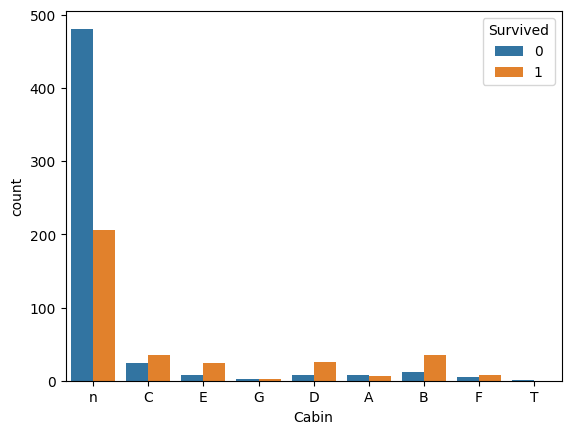

In [153]:
sns.countplot(data = df, x = 'Cabin', hue = 'Survived')

In [154]:
X_train_final.sample(10)

,Age,Fare,FamilySize,Pclass,Sex,Cabin,Embarked,Title
531,18.0,7.775,1.0,3,male,G,S,Mr
113,28.5,8.05,1.0,3,male,G,S,Mr
410,28.5,89.1042,2.0,1,female,C,C,Mrs
475,65.0,61.9792,2.0,1,male,B,C,Mr
669,30.0,93.5,1.0,1,female,B,S,Miss
681,5.0,27.75,4.0,2,female,G,S,Miss
407,45.0,14.4542,2.0,3,female,G,C,Mrs
415,39.0,31.275,7.0,3,male,G,S,Mr
201,52.0,79.65,3.0,1,male,E,S,Mr
52,4.0,27.9,6.0,3,male,G,S,Master


In [155]:
ohe_features = ['Sex','Cabin','Embarked','Title']

encoder_transformer = ColumnTransformer(
    transformers = [
        ('encoder',OneHotEncoder(drop = 'first', sparse_output = False), ohe_features)
    ],
    remainder = 'passthrough'
)

In [156]:
X_train_enc = encoder_transformer.fit_transform(X_train_final)
X_test_enc = encoder_transformer.transform(X_test_final)

In [157]:
X_train_enc

array([[1.0, 0.0, 0.0, ..., 56.4958, 1.0, 3],
       [1.0, 0.0, 0.0, ..., 0.0, 1.0, 2],
       [1.0, 0.0, 1.0, ..., 221.7792, 1.0, 1],
       ...,
       [0.0, 0.0, 0.0, ..., 34.375, 5.0, 3],
       [1.0, 0.0, 0.0, ..., 38.5, 1.0, 1],
       [1.0, 0.0, 0.0, ..., 26.55, 1.0, 1]], dtype=object)

In [160]:
encoded_columns = encoder_transformer.get_feature_names_out()

print(len(encoded_columns))
print(X_train_enc.shape)

18
(712, 18)


In [161]:
X_train_enc = pd.DataFrame(
    X_train_enc,
    columns=encoded_columns,
    index=X_train_final.index
)

X_test_enc = pd.DataFrame(
    X_test_enc,
    columns=encoded_columns,
    index=X_test_final.index
)

In [162]:
print(X_train_enc.columns.tolist())

['encoder__Sex_male', 'encoder__Cabin_B', 'encoder__Cabin_C', 'encoder__Cabin_D', 'encoder__Cabin_E', 'encoder__Cabin_F', 'encoder__Cabin_G', 'encoder__Cabin_T', 'encoder__Embarked_Q', 'encoder__Embarked_S', 'encoder__Title_Miss', 'encoder__Title_Mr', 'encoder__Title_Mrs', 'encoder__Title_Rare', 'remainder__Age', 'remainder__Fare', 'remainder__FamilySize', 'remainder__Pclass']


In [163]:
X_train_enc

,encoder__Sex_male,encoder__Cabin_B,encoder__Cabin_C,encoder__Cabin_D,encoder__Cabin_E,encoder__Cabin_F,encoder__Cabin_G,encoder__Cabin_T,encoder__Embarked_Q,encoder__Embarked_S,encoder__Title_Miss,encoder__Title_Mr,encoder__Title_Mrs,encoder__Title_Rare,remainder__Age,remainder__Fare,remainder__FamilySize,remainder__Pclass
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,56.4958,1.0,3
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,0.0,1.0,2
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,221.7792,1.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,18.0,9.35,2.0,3
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,31.0,26.25,3.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,28.5,7.8792,1.0,3
708,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,35.0,512.3292,1.0,1
709,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,48.0,34.375,5.0,3
710,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,47.0,38.5,1.0,1


In [164]:
X_train_enc.remainder__Fare.describe()

count     712.0
unique    226.0
top        13.0
freq       33.0
Name: remainder__Fare, dtype: float64

In [166]:
X_train_enc.remainder__Fare.max()

512.3292

In [167]:
X_train_enc.remainder__Fare.min()

0.0

In [168]:
X_train_enc.remainder__Fare.mean()

31.819826264044874

In [169]:
X_train_enc.remainder__Fare.median()

14.4542

In [171]:
scaler = RobustScaler()

X_train_enc[['remainder__Fare']] = scaler.fit_transform(
    X_train_enc[['remainder__Fare']]
)

X_test_enc[['remainder__Fare']] = scaler.transform(
    X_test_enc[['remainder__Fare']]
)

In [172]:
X_train_enc.head()

,encoder__Sex_male,encoder__Cabin_B,encoder__Cabin_C,encoder__Cabin_D,encoder__Cabin_E,encoder__Cabin_F,encoder__Cabin_G,encoder__Cabin_T,encoder__Embarked_Q,encoder__Embarked_S,encoder__Title_Miss,encoder__Title_Mr,encoder__Title_Mrs,encoder__Title_Rare,remainder__Age,remainder__Fare,remainder__FamilySize,remainder__Pclass
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,1.819652,1.0,3
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,-0.625609,1.0,2
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.5,8.973477,1.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,18.0,-0.220921,2.0,3
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,31.0,0.510548,3.0,2


<Axes: xlabel='Age', ylabel='Count'>

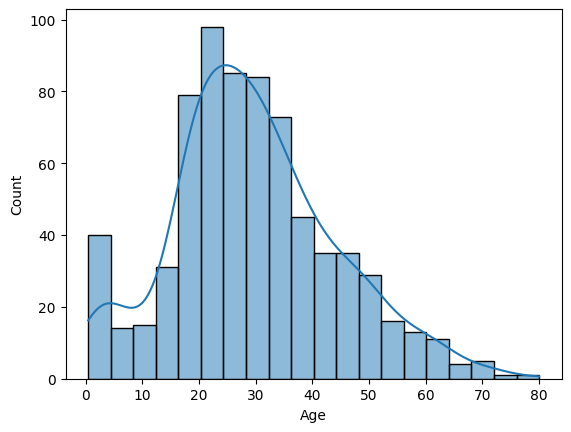

In [176]:
sns.histplot(data = df, x = 'Age', kde = True)

In [ ]:
scaler = Scaler()

X_train_enc[['remainder__Fare']] = scaler.fit_transform(
    X_train_enc[['remainder__Fare']]
)

X_test_enc[['remainder__Fare']] = scaler.transform(
    X_test_enc[['remainder__Fare']]
)

In [177]:
scaler_age = StandardScaler()

X_train_enc[['remainder__Age']] = scaler_age.fit_transform(
    X_train_enc[['remainder__Age']]
)

X_test_enc[['remainder__Age']] = scaler_age.transform(
    X_test_enc[['remainder__Age']]
)

In [178]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_enc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [179]:
y_pred = model.predict(X_test_enc)
y_pred_proba = model.predict_proba(X_test_enc)[:, 1]

In [180]:
y_pred_proba

array([0.0525012 , 0.03490271, 0.14032194, 0.02778272, 0.64001987,
       0.63727824, 0.65970531, 0.52794163, 0.2493722 , 0.09558329,
       0.140786  , 0.06772192, 0.57582536, 0.11507095, 0.30208822,
       0.1570634 , 0.2618371 , 0.08000251, 0.11677243, 0.67599955,
       0.08000251, 0.6114592 , 0.07603976, 0.56777691, 0.07861345,
       0.97933085, 0.34616273, 0.20715224, 0.1123228 , 0.11668345,
       0.06633839, 0.94896301, 0.34575544, 0.241876  , 0.42237682,
       0.46325143, 0.42662014, 0.18072488, 0.140786  , 0.65627489,
       0.21149277, 0.93925   , 0.07783319, 0.79421494, 0.67453286,
       0.10272711, 0.08040423, 0.59553019, 0.66637476, 0.81974216,
       0.83362174, 0.56242973, 0.70767344, 0.14730934, 0.76106822,
       0.08702761, 0.06006966, 0.60155961, 0.62832207, 0.22458472,
       0.77242383, 0.66908741, 0.12087378, 0.08707613, 0.31824849,
       0.49941361, 0.94332451, 0.06899912, 0.35520204, 0.1693047 ,
       0.86492348, 0.11391261, 0.55184417, 0.94938254, 0.12742

In [181]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8212290502793296

Confusion Matrix:
 [[98 12]
 [20 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


ROC AUC Score: 0.8666666666666667


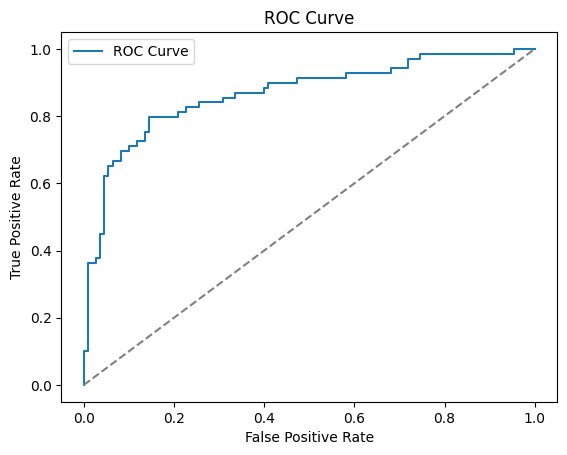

In [182]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()